# NumPy vs Rust(레거시) vs Rust(최적) 전처리 속도 비교

같은 분자 블록에 대해 아래 경로들의 **벽시계 시간**과 단계별 누적 시간을 비교합니다. 모든 행은 실제로 파이프라인을 한 번씩 돌린 수치입니다. `qdf_io`가 없거나 스크립트 경로가 잘못되면 **셀 실행이 예외로 중단**됩니다(표·그래프에 N/A 플레이스홀더를 두지 않음).

**바인딩 표시(필수):** 각 실행 직후 `bench_meta`가 stdout에 찍히고, 아래 표에는 `meta__*` 열로 **실제로 호출된 심볼**이 남습니다. `rust-legacy`가 **외부 구 `.so`의 `preprocess_batch_rust`**인지, **`qdf_io.preprocess_batch_rust_legacy`(트리 내 레거시 수학)**인지 혼동하지 않도록 구분합니다. 동결 드라이버는 외부 `.so`를 쓰지 않으며 `meta__frozen_pre_agent_note`에 기록됩니다.

| 백엔드 | 의미 |
|--------|------|
| **numpy** | `train/preprocess.py`와 동일한 순수 NumPy/SciPy 루프 |
| **rust-legacy** | **현재** `profile_preprocess.py`: 구 `.so`가 지정되면 그 확장의 `preprocess_batch_rust`(당시 바이너리)만 로드; 지정이 없으면 **`preprocess_batch_rust_legacy`만** (`process_one_legacy`; **`preprocess_batch_rust`로 대체하지 않음**). 심볼이 없으면 예외 — `maturin develop --release`로 재빌드. **동결** `profile_preprocess_pre_agent.py`는 항상 `preprocess_batch_rust_legacy`만(외부 `.so` 인자 무시). |
| **rust** | **지금 소스로 빌드한** `qdf_io.preprocess_batch_rust`(최적화 반영). |

**벤치 드라이버 (표·그래프 동일 순서)**

| `bench_driver` (그래프·표에 표시) | 의미 |
|----------------|------|
| **`Minimal (numpy + rust opt)`** | numpy + rust(opt) 만 (현재 `profile_preprocess.py`). |
| **`profile_preprocess.py (all backends)`** | 같은 모듈로 numpy / rust-legacy / rust(opt) 전부. |
| **`Frozen: profile_preprocess_pre_agent.py`** | 기본값으로 리포의 `bench/profile_preprocess_pre_agent.py`를 `importlib`로 로드해 동일 백엔드 조합 실행. 다른 파일을 쓰려면 `QDF_PRE_AGENT_PROFILE_PREPROCESS` 또는 `PRE_AGENT_PROFILE_SCRIPT`로 경로 지정. |

**전제**

- 구 네이티브(선택): `QDF_IO_LEGACY_NATIVE_PATH` 또는 `LEGACY_NATIVE_PATH` — **현재** `profile_preprocess.py`의 `rust-legacy`에만 전달.
- 기본 **`no_save=True`**.

In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np

HERE = Path.cwd().resolve()
for cand in (HERE, HERE.parent, HERE.parent.parent):
    qdf = cand / "QuantumDeepField_molecule"
    if (qdf / "bench" / "profile_preprocess.py").is_file():
        QDF_ROOT = qdf
        break
else:
    raise FileNotFoundError(
        "QuantumDeepField_molecule/bench/profile_preprocess.py 를 찾을 수 없습니다. "
        "노트북을 QuantumDeepField_molecule/bench 에서 열거나 repo 루트에서 실행하세요."
    )

REPO_ROOT = QDF_ROOT.parent
sys.path.insert(0, str(QDF_ROOT / "train"))

_spec = importlib.util.spec_from_file_location(
    "profile_preprocess",
    QDF_ROOT / "bench" / "profile_preprocess.py",
)
_pp = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_pp)

profile_preprocess_mod = _pp
time_preprocess_pipeline = _pp.time_preprocess_pipeline
load_dataset_blocks = _pp.load_dataset_blocks

print("QDF_ROOT:", QDF_ROOT)
print("REPO_ROOT:", REPO_ROOT)

QDF_ROOT: /home/ubuntu/3DGCL/QuantumDeepField_molecule
REPO_ROOT: /home/ubuntu/3DGCL


In [2]:
# ---- 설정 (필요에 맞게 수정) ----
DATASET = "QM9under14atoms_atomizationenergy_eV"
SPLIT = "train"
LIMIT = 500  # 빠른 확인은 100~500, 차이를 크게 보려면 2000+
RUST_BATCH_SIZE = 64
BASIS_SET = "6-31G"
RADIUS = 0.75
GRID_INTERVAL = 0.3
NO_SAVE = True  # True: np.save 제외(기하 위주). False: 디스크 포함

HAS_PROPERTY = SPLIT in {"train", "val", "test"} and DATASET.endswith("_eV")

src = QDF_ROOT / "dataset" / DATASET / f"{SPLIT}.txt"
if not src.exists():
    raise FileNotFoundError(src)

blocks = load_dataset_blocks(src)
if LIMIT:
    blocks = blocks[:LIMIT]
n_mol = len(blocks)
print(f"Dataset: {DATASET} / {SPLIT}  —  {n_mol} molecules")

import os

# 선택: 수정 전에 빌드해 둔 구 네이티브(.so / .pyd). 파일이 있으면 **현재** profile_preprocess 의 rust-legacy에만 전달.
_leg = os.environ.get("QDF_IO_LEGACY_NATIVE_PATH", os.environ.get("LEGACY_NATIVE_PATH", "")).strip()
LEGACY_NATIVE_PATH = Path(_leg).expanduser() if _leg else Path()
# LEGACY_NATIVE_PATH = Path("/path/to/libqdf_io_pre_change.so")

_pre_env = os.environ.get(
    "QDF_PRE_AGENT_PROFILE_PREPROCESS", os.environ.get("PRE_AGENT_PROFILE_SCRIPT", "")
).strip()
PRE_AGENT_PROFILE_SCRIPT = (
    Path(_pre_env).expanduser()
    if _pre_env
    else QDF_ROOT / "bench" / "profile_preprocess_pre_agent.py"
)
if not PRE_AGENT_PROFILE_SCRIPT.is_file():
    raise FileNotFoundError(
        "동결 벤치 스크립트를 찾을 수 없습니다: "
        f"{PRE_AGENT_PROFILE_SCRIPT}\n"
        "리포에 bench/profile_preprocess_pre_agent.py 가 있어야 하거나, "
        "QDF_PRE_AGENT_PROFILE_PREPROCESS / PRE_AGENT_PROFILE_SCRIPT 로 경로를 지정하세요."
    )

print(
    "LEGACY_NATIVE_PATH:",
    str(LEGACY_NATIVE_PATH) if _leg else "(비어 있음 — 현재 rust-legacy는 qdf_io 레거시로 진행)",
)
print("PRE_AGENT_PROFILE_SCRIPT:", PRE_AGENT_PROFILE_SCRIPT)

Dataset: QM9under14atoms_atomizationenergy_eV / train  —  500 molecules
LEGACY_NATIVE_PATH: (비어 있음 — 현재 rust-legacy는 qdf_io 레거시로 진행)
PRE_AGENT_PROFILE_SCRIPT: /home/ubuntu/3DGCL/QuantumDeepField_molecule/bench/profile_preprocess_pre_agent.py


In [3]:
import inspect


def load_pp_module(path: Path, unique_name: str):
    spec = importlib.util.spec_from_file_location(unique_name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load {path}")
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


_pp_pre = load_pp_module(
    PRE_AGENT_PROFILE_SCRIPT,
    "profile_preprocess_pre_agent_nb",
)

DRIVER_MINIMAL = "Minimal (numpy + rust opt)"
DRIVER_CURRENT = "profile_preprocess.py (all backends)"
PRE_AGENT_DRIVER_LABEL = "Frozen: profile_preprocess_pre_agent.py"


def pp_supports_legacy_native_kw(mod) -> bool:
    return "rust_legacy_native_path" in inspect.signature(mod.time_preprocess_pipeline).parameters


def tpp_kwargs(mod, backend: str) -> dict:
    kw = dict(
        blocks=blocks,
        backend=backend,
        rust_batch_size=RUST_BATCH_SIZE,
        basis_set=BASIS_SET,
        radius=RADIUS,
        grid_interval=GRID_INTERVAL,
        has_property=HAS_PROPERTY,
        no_save=NO_SAVE,
    )
    if pp_supports_legacy_native_kw(mod):
        use_native = backend == "rust-legacy" and LEGACY_NATIVE_PATH.is_file()
        kw["rust_legacy_native_path"] = LEGACY_NATIVE_PATH if use_native else None
    return kw


BACKENDS_FULL = [
    ("numpy", "Python NumPy"),
    (
        "rust-legacy",
        "Rust legacy (old .so if set, else preprocess_batch_rust_legacy only)",
    ),
    ("rust", "Rust (preprocess_batch_rust, optimized)"),
]
BACKENDS_MIN = [
    ("numpy", "Python NumPy"),
    ("rust", "Rust (preprocess_batch_rust, optimized)"),
]


def collect_runs(
    pp_mod,
    driver: str,
    backends: list[tuple[str, str]],
) -> list[dict]:
    out: list[dict] = []
    for backend, label in backends:
        print("\n" + "=" * 60)
        print(driver, "|", label, f"backend={backend!r}")
        print("=" * 60)
        wall, timings, n, _, bench_meta = pp_mod.time_preprocess_pipeline(
            **tpp_kwargs(pp_mod, backend)
        )
        assert n == n_mol
        ms = 1000.0 * wall / n_mol if n_mol else 0.0
        row = {
            "bench_driver": driver,
            "label": label,
            "backend": backend,
            "wall_s": wall,
            "ms_per_molecule": ms,
            **{f"step__{k}": v for k, v in timings.items()},
            **{f"meta__{k}": str(v) for k, v in bench_meta.items()},
        }
        out.append(row)
        print(f"wall: {wall:.4f} s  ({ms:.3f} ms/molecule)")
    return out


runs_table: list[dict] = []
runs_table.extend(
    collect_runs(
        profile_preprocess_mod,
        DRIVER_MINIMAL,
        BACKENDS_MIN,
    )
)
runs_table.extend(
    collect_runs(
        profile_preprocess_mod,
        DRIVER_CURRENT,
        BACKENDS_FULL,
    )
)
runs_table.extend(
    collect_runs(
        _pp_pre,
        PRE_AGENT_DRIVER_LABEL,
        BACKENDS_FULL,
    )
)

runs = runs_table


Minimal (numpy + rust opt) | Python NumPy backend='numpy'
Temp save dir: /tmp/qdf_bench_304stkqq
bench_meta: frozen_pre_agent_note='' | legacy_native_so_path='' | qdf_io_package_path='' | rust_batch_entrypoint='pure_python_numpy' | rust_batch_fn_repr='' | uses_external_legacy_native_so='n/a'
wall: 1.6004 s  (3.201 ms/molecule)

Minimal (numpy + rust opt) | Rust (preprocess_batch_rust, optimized) backend='rust'
Temp save dir: /tmp/qdf_bench_trojlu0m
bench_meta: frozen_pre_agent_note='' | legacy_native_so_path='' | qdf_io_package_path='/home/ubuntu/3DGCL/QuantumDeepField_molecule/qdf_io/python/qdf_io/__init__.py' | rust_batch_entrypoint='qdf_io.preprocess_batch_rust' | rust_batch_fn_repr='<built-in function preprocess_batch_rust>' | uses_external_legacy_native_so='n/a'
wall: 0.0750 s  (0.150 ms/molecule)

profile_preprocess.py (all backends) | Python NumPy backend='numpy'
Temp save dir: /tmp/qdf_bench_x177fs5j
bench_meta: frozen_pre_agent_note='' | legacy_native_so_path='' | qdf_io_pack

In [4]:
try:
    import pandas as pd

    df = pd.DataFrame(runs_table)
    cols = ["bench_driver", "label", "backend", "wall_s", "ms_per_molecule"]
    meta_cols = sorted(c for c in df.columns if c.startswith("meta__"))
    extra = sorted(c for c in df.columns if c.startswith("step__"))
    err = ["error"] if "error" in df.columns else []
    display(df[cols + meta_cols + extra + err])
except ImportError:
    for r in runs_table:
        print(r)

,bench_driver,label,backend,wall_s,ms_per_molecule,meta__frozen_pre_agent_note,meta__legacy_native_so_path,meta__qdf_io_package_path,meta__rust_batch_entrypoint,meta__rust_batch_fn_repr,meta__uses_external_legacy_native_so,step__assemble,step__create_field,step__distmat_atoms,step__distmat_orbitals,step__parse_molecule,step__potential,step__rust_pack_inputs,step__rust_preprocess_batch,step__sphere_once
0,Minimal (numpy + rust opt),Python NumPy,numpy,1.600408,3.200816,,,,pure_python_numpy,,n/a,0.019486,0.186890,0.154410,1.119341,0.039871,0.077489,NaN,NaN,0.000240
1,Minimal (numpy + rust opt),"Rust (preprocess_batch_rust, optimized)",rust,0.074975,0.149951,,,/home/ubuntu/3DGCL/QuantumDeepField_molecule/q...,qdf_io.preprocess_batch_rust,<built-in function preprocess_batch_rust>,n/a,0.001877,NaN,NaN,NaN,0.020475,NaN,0.000229,0.050773,0.000284
2,profile_preprocess.py (all backends),Python NumPy,numpy,1.507273,3.014547,,,,pure_python_numpy,,n/a,0.019488,0.187973,0.150936,1.057704,0.039368,0.048939,NaN,NaN,0.000215
3,profile_preprocess.py (all backends),"Rust legacy (old .so if set, else preprocess_b...",rust-legacy,0.078501,0.157002,,,/home/ubuntu/3DGCL/QuantumDeepField_molecule/q...,qdf_io.preprocess_batch_rust_legacy,<built-in function preprocess_batch_rust_legacy>,no,0.001977,NaN,NaN,NaN,0.020544,NaN,0.000215,0.054027,0.000216
4,profile_preprocess.py (all backends),"Rust (preprocess_batch_rust, optimized)",rust,0.091514,0.183029,,,/home/ubuntu/3DGCL/QuantumDeepField_molecule/q...,qdf_io.preprocess_batch_rust,<built-in function preprocess_batch_rust>,n/a,0.002104,NaN,NaN,NaN,0.021976,NaN,0.000227,0.065394,0.000248
5,Frozen: profile_preprocess_pre_agent.py,Python NumPy,numpy,1.621530,3.243060,,,,pure_python_numpy,,n/a,0.019386,0.187191,0.150720,1.103652,0.045245,0.112165,NaN,NaN,0.000218
6,Frozen: profile_preprocess_pre_agent.py,"Rust legacy (old .so if set, else preprocess_b...",rust-legacy,0.080855,0.161709,profile_preprocess_pre_agent.py: never loads e...,,/home/ubuntu/3DGCL/QuantumDeepField_molecule/q...,qdf_io.preprocess_batch_rust_legacy,<built-in function preprocess_batch_rust_legacy>,no,0.002089,NaN,NaN,NaN,0.020819,NaN,0.000223,0.055850,0.000216
7,Frozen: profile_preprocess_pre_agent.py,"Rust (preprocess_batch_rust, optimized)",rust,0.073202,0.146405,,,/home/ubuntu/3DGCL/QuantumDeepField_molecule/q...,qdf_io.preprocess_batch_rust,<built-in function preprocess_batch_rust>,n/a,0.002081,NaN,NaN,NaN,0.020541,NaN,0.000213,0.048738,0.000218


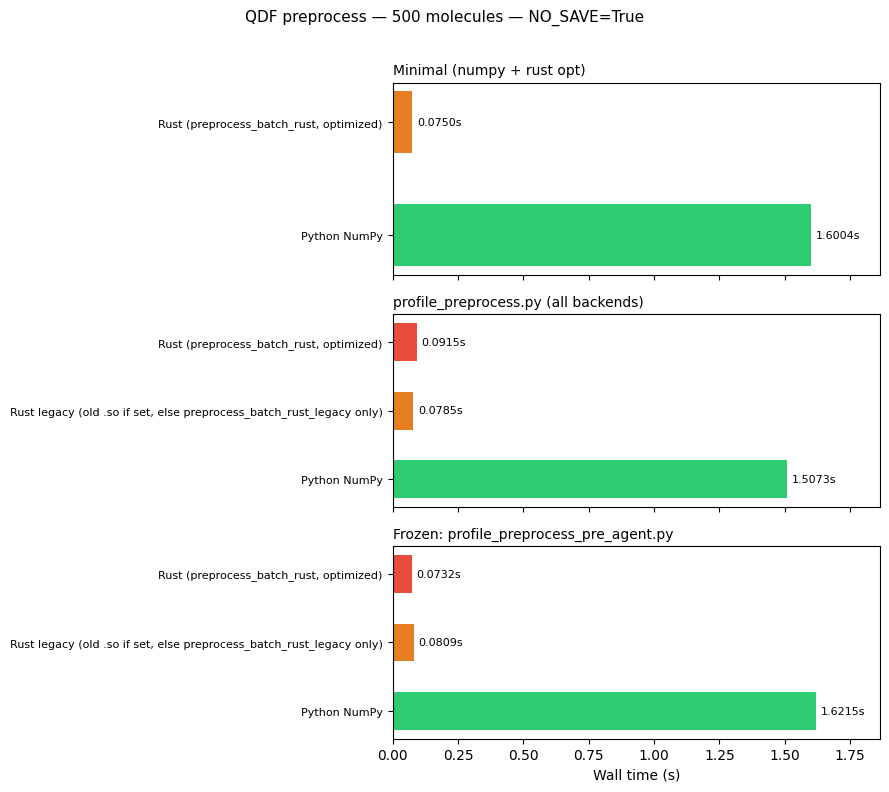

[profile_preprocess.py (all backends)] numpy / rust(opt): 16.47x
[profile_preprocess.py (all backends)] rust(legacy) / rust(opt): 0.86x


In [5]:
import matplotlib.pyplot as plt

if not runs_table:
    print("runs_table is empty; run the cells above first.")
else:
    driver_order = [DRIVER_MINIMAL, DRIVER_CURRENT, PRE_AGENT_DRIVER_LABEL]

    def finite_max(rows):
        vals = [float(r["wall_s"]) for r in rows]
        return max(vals) if vals else 1.0

    xmax_all = finite_max(runs_table) * 1.15

    fig, axes = plt.subplots(len(driver_order), 1, figsize=(9, 2.6 * len(driver_order)), sharex=True)
    if len(driver_order) == 1:
        axes = [axes]

    palette = ["#2ecc71", "#e67e22", "#e74c3c"]

    for ax, driver in zip(axes, driver_order):
        rows = [r for r in runs_table if r["bench_driver"] == driver]
        labels = [r["label"] for r in rows]
        walls_raw = [r["wall_s"] for r in rows]
        y = np.arange(len(labels))
        colors = [palette[i % len(palette)] for i in range(len(labels))]
        xmax = finite_max(rows) if rows else 1.0
        xmax = max(xmax, 1e-6)

        for yi, w, c in zip(y, walls_raw, colors):
            wf = float(w)
            ax.barh(yi, wf, height=0.55, color=c)
            ax.text(wf + 0.01 * xmax_all, yi, f"{wf:.4f}s", va="center", fontsize=8)

        ax.set_yticks(y, labels, fontsize=8)
        ax.set_title(driver, fontsize=10, loc="left")
        ax.set_xlim(0, xmax_all)

    axes[-1].set_xlabel("Wall time (s)")
    fig.suptitle(f"QDF preprocess — {n_mol} molecules — NO_SAVE={NO_SAVE}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    cur = [r for r in runs_table if r["bench_driver"] == DRIVER_CURRENT]
    by = {r["backend"]: float(r["wall_s"]) for r in cur}
    w_np = by.get("numpy")
    w_opt = by.get("rust")
    w_leg = by.get("rust-legacy")
    if w_np is not None and w_opt and w_opt > 0:
        print(f"[{DRIVER_CURRENT}] numpy / rust(opt): {w_np / w_opt:.2f}x")
    if w_leg is not None and w_opt and w_opt > 0:
        print(f"[{DRIVER_CURRENT}] rust(legacy) / rust(opt): {w_leg / w_opt:.2f}x")